In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import pycountry_convert as pcc
import plotly.graph_objects as go
import plotly.subplots
import random
from plotly.offline import iplot
import geopandas as gpd

# Общее
Максимально использовать Pandas и Plotly или Bokeh или GeoPandas (для визуализации карты Мира со странами). Применение излишних циклов ведет к снижению баллов (циклы - ЗЛО). Применение ненужных функций - аналогично. Используйте apply, map и lambda по максимуму. Помним про корректное применение сортировок.

Вспоминаем английский:

csv_airports_v1.csv:
- `Airport ID`	Unique OpenFlights identifier for this airport.
- `Name of airport`. May or may not contain the City name.
- `City`	Main city served by airport. May be spelled differently from Name.
- `Country`	Country or territory where airport is located. See Countries to cross-reference to ISO 3166-1 codes.
- `IATA`	3-letter IATA code. Null if not assigned/unknown.
- `ICAO`	4-letter ICAO code. Null if not assigned.
- `Latitude`	Decimal degrees, usually to six significant digits. Negative is South, positive is North.
- `Longitude`	Decimal degrees, usually to six significant digits. Negative is West, positive is East.
- `Altitude`	In feet.
- `Timezone`	Hours offset from UTC. Fractional hours are expressed as decimals, eg. India is 5.5.
- `DST`	Daylight savings time. One of E (Europe), A (US/Canada), S (South America), O (Australia), Z (New Zealand), N (None) or U (Unknown). See also: Help: Time
- `Tz database timezone`	Timezone in "tz" (Olson) format, eg. "America/Los_Angeles".


csv_routes_v1.csv:
- `Airline`	2-letter (IATA) or 3-letter (ICAO) code of the airline.
- `Airline ID`	Unique OpenFlights identifier for airline (see Airline).
- `Source airport`	3-letter (IATA) or 4-letter (ICAO) code of the source airport.
- `Source airport ID`	Unique OpenFlights identifier for source airport (see Airport)
- `Destination airport`	3-letter (IATA) or 4-letter (ICAO) code of the destination airport.
- `Destination airport ID`	Unique OpenFlights identifier for destination airport (see Airport)
- `Equipment`	3-letter codes for plane type(s) generally used on this flight, separated by spaces

## Задание 1 
Скачать данные из `csv_airports_v1.csv` и `csv_routes_v1.csv` в виде датафрейма в переменные `airports` и `routes`.

In [2]:
airports = pd.read_csv("csv_airports_v1.csv")
routes = pd.read_csv("csv_routes_v1.csv")


In [3]:
display(airports.tail(3))
display(routes.head(3))

,Airport ID,Name of airport,City,Country,IATA,ICAO,Latitude,Longitude,Altitude,Timezone,DST,Tz database timezone
7694,14108,Krechevitsy Air Base,Novgorod,Russia,\N,ULLK,58.625000,31.385000,85,\N,\N,\N
7695,14109,Desierto de Atacama Airport,Copiapo,Chile,CPO,SCAT,-27.261200,-70.779198,670,\N,\N,\N
7696,14110,Melitopol Air Base,Melitopol,Ukraine,\N,UKDM,46.880001,35.305000,0,\N,\N,\N


,Airline,Airline ID,Source airport,Source airport ID,Destination airport,Destination airport ID,Equipment
0,2B,410,ASF,2966,KZN,2990,CR2
1,2B,410,ASF,2966,MRV,2962,CR2
2,2B,410,CEK,2968,KZN,2990,CR2


## Задание 2. 
1. Вывести `info` по датафреймам.
2. Обратите внимание, что в `csv_airports_v1.csv` пропущенные данные закодированы как `\N` заменить их на стандартные `np.nan`
3. Повторно посмотреть `info` по датафреймам.

In [4]:
airports.info()
routes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7697 entries, 0 to 7696
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Airport ID            7697 non-null   int64  
 1   Name of airport       7697 non-null   object 
 2   City                  7648 non-null   object 
 3   Country               7697 non-null   object 
 4   IATA                  7697 non-null   object 
 5   ICAO                  7697 non-null   object 
 6   Latitude              7697 non-null   float64
 7   Longitude             7697 non-null   float64
 8   Altitude              7697 non-null   int64  
 9   Timezone              7697 non-null   object 
 10  DST                   7697 non-null   object 
 11  Tz database timezone  7697 non-null   object 
dtypes: float64(2), int64(2), object(8)
memory usage: 721.7+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67662 entries, 0 to 67661
Data columns (total 7 columns):
 #   Co

In [5]:
airports = airports.replace("\\N", np.nan)    # заменяем пропуски
airports.info()
routes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7697 entries, 0 to 7696
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Airport ID            7697 non-null   int64  
 1   Name of airport       7697 non-null   object 
 2   City                  7648 non-null   object 
 3   Country               7697 non-null   object 
 4   IATA                  6071 non-null   object 
 5   ICAO                  7696 non-null   object 
 6   Latitude              7697 non-null   float64
 7   Longitude             7697 non-null   float64
 8   Altitude              7697 non-null   int64  
 9   Timezone              7344 non-null   object 
 10  DST                   7344 non-null   object 
 11  Tz database timezone  6676 non-null   object 
dtypes: float64(2), int64(2), object(8)
memory usage: 721.7+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67662 entries, 0 to 67661
Data columns (total 7 columns):
 #   Co

## Задание 3. 
1. Срезать данные в `airports` по наличию кода `IATA` в переменую `iata_arports`, отвяжите новую табличку от `airports`
2. В `iata_arports` добавьте столбец `Continents` с названием континента, на котором размещен аэропорт (Северная и Южная Америка разные континенты, Россия в Европе, Турция в Азии). 

In [6]:
iata_arports = airports[airports["IATA"].notna()]   #срезаем данные
iata_arports = iata_arports.copy()   #отвязываем таблицу
iata_arports.tail(3)

,Airport ID,Name of airport,City,Country,IATA,ICAO,Latitude,Longitude,Altitude,Timezone,DST,Tz database timezone
7687,14101,Rustaq Airport,Al Masna'ah,Oman,MNH,OORQ,23.640556,57.487500,349,NaN,NaN,NaN
7688,14102,Laguindingan Airport,Cagayan de Oro City,Philippines,CGY,RPMY,8.612203,124.456496,190,NaN,NaN,NaN
7695,14109,Desierto de Atacama Airport,Copiapo,Chile,CPO,SCAT,-27.261200,-70.779198,670,NaN,NaN,NaN


In [7]:
# Создаем функцию для добавления континента по названию страны
def country_to_continent(country_name):
    try:
        country_alpha2 = pcc.country_name_to_country_alpha2(country_name)
        country_continent_code = pcc.country_alpha2_to_continent_code(country_alpha2)
        country_continent_name = pcc.convert_continent_code_to_continent_name(country_continent_code)
        if country_alpha2 == None:
            country_continent_name = country_dict['country_name']
        return country_continent_name
    except:
        return None
    
iata_arports['Continents'] = iata_arports['Country'].map(country_to_continent)
cont_list = iata_arports['Continents'].unique()   # создаем список континентов
cont_list = list(filter(lambda x: x is not None, cont_list))
print(cont_list)


['Oceania', 'North America', 'Europe', 'Africa', 'South America', 'Asia']


C:\Users\zvlad\anaconda3\Lib\site-packages\pycountry\db.py:51: UserWarning:

Country's official_name not found. Country name provided instead.

C:\Users\zvlad\anaconda3\Lib\site-packages\pycountry\db.py:51: UserWarning:

Country's common_name not found. Country name provided instead.



## Задание 4.
Реализовать случайный выбор континента и на карте Мира нанести точки аэропортов `iata_arports` для выбранного континента.

Реализуйте все континенты на отдельных `subplots`.
Нашли обшибки в данных, если да то какие?

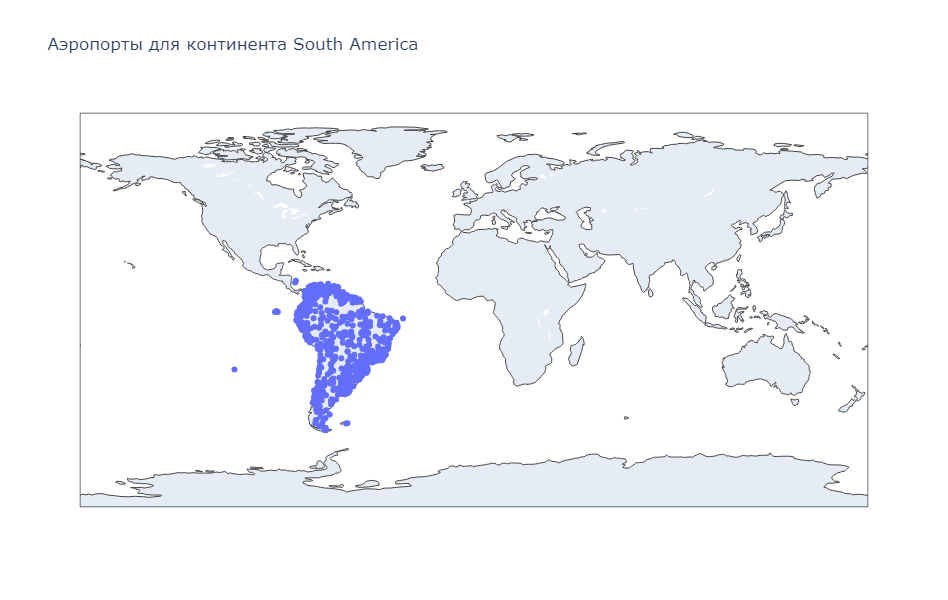

In [8]:
#Для случайного континента
rand_cont = random.choice(cont_list) 
fig = go.Figure(data=go.Scattergeo(
        lon = iata_arports[iata_arports.Continents == rand_cont]['Longitude'],
        lat = iata_arports[iata_arports.Continents == rand_cont]['Latitude']), 
                layout=go.Layout(height=600, width=800, 
                                title=go.layout.Title(text=f"Аэропорты для континента {rand_cont}"))
               )
fig.show()

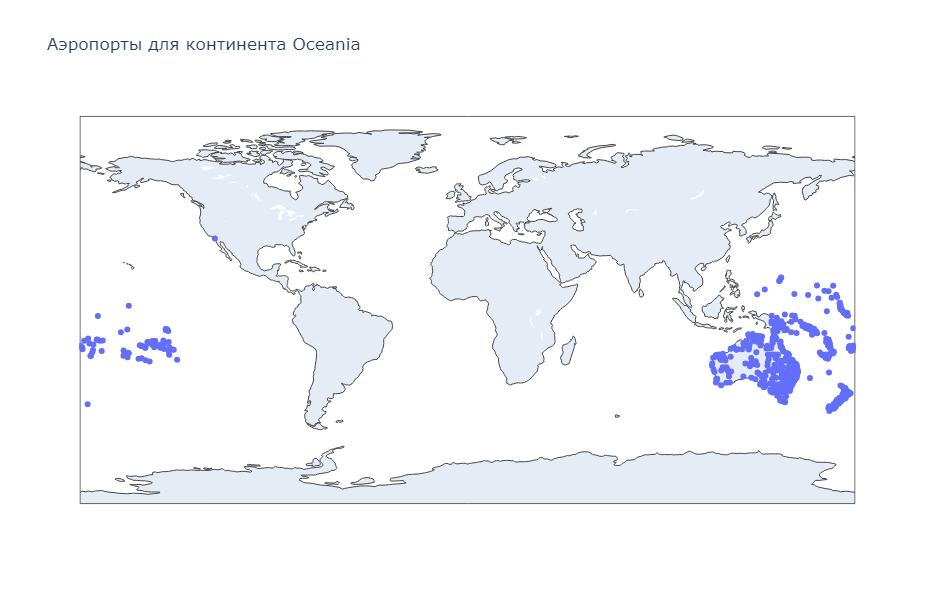

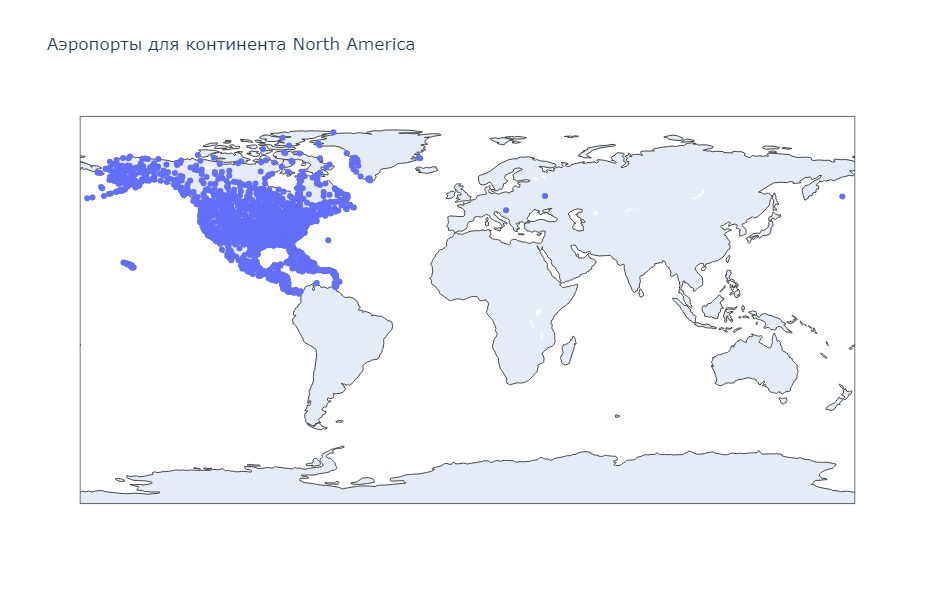

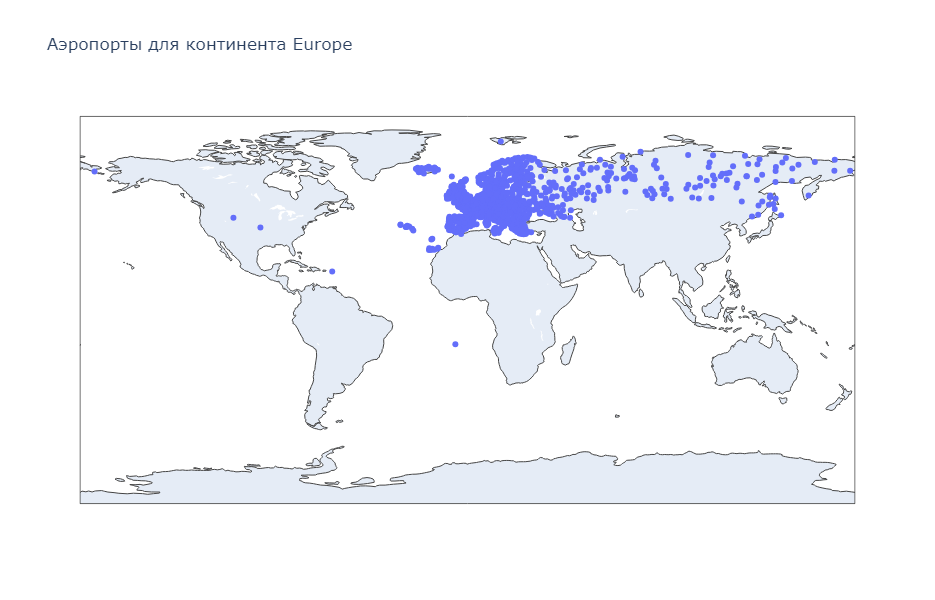

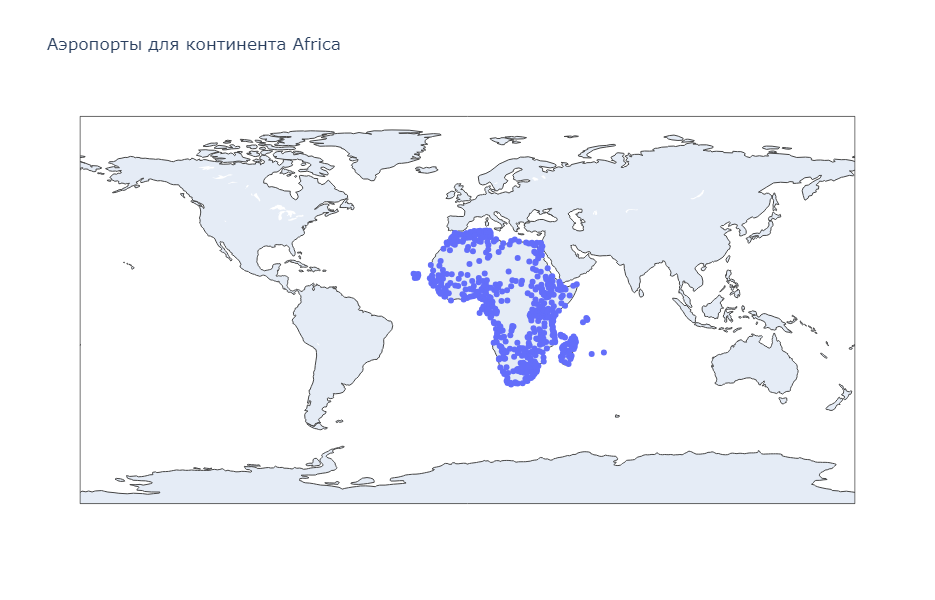

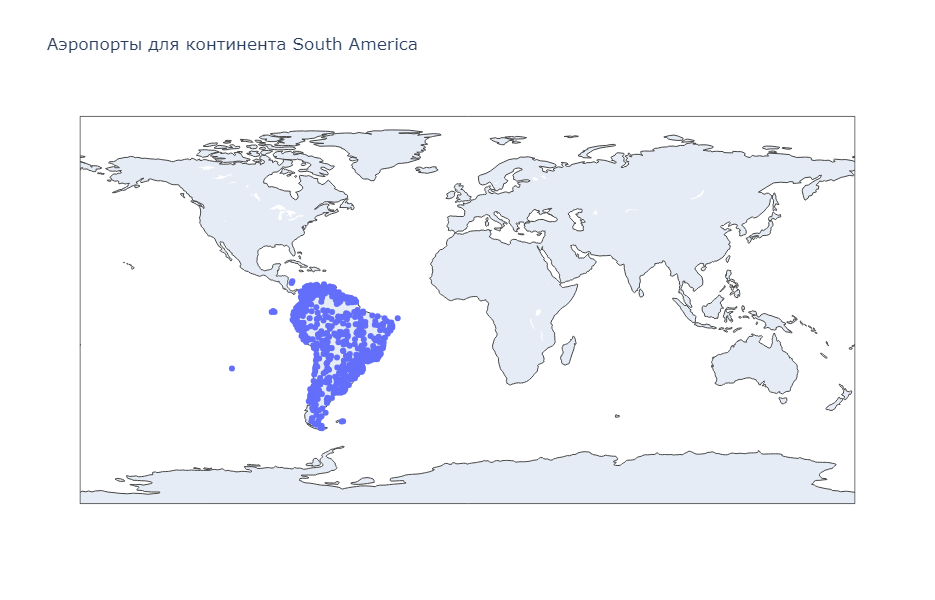

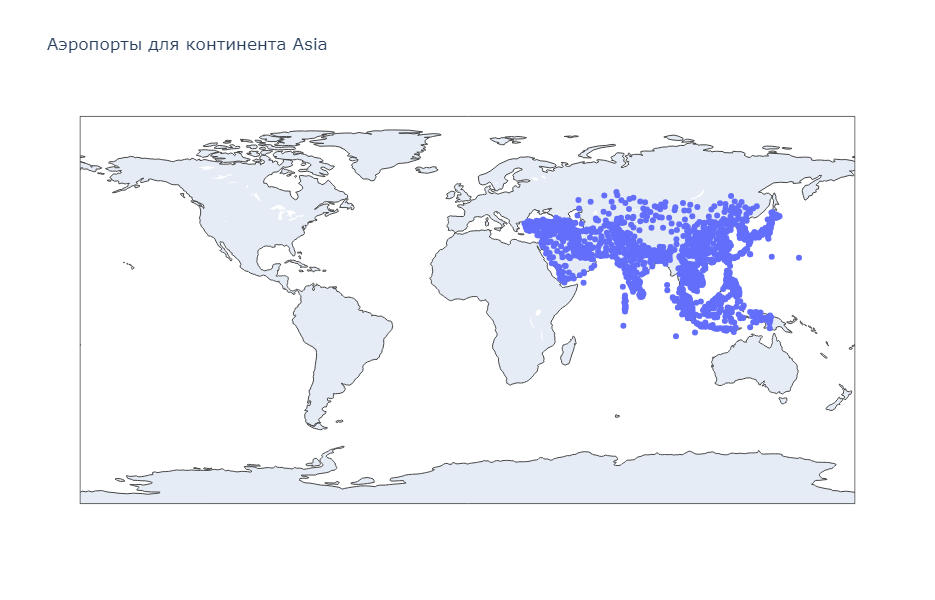

In [9]:
# Для всех континентов в отдельности
for i in cont_list:
    fig = go.Figure(data=go.Scattergeo(
        lon = iata_arports[iata_arports.Continents == i]['Longitude'],
        lat = iata_arports[iata_arports.Continents == i]['Latitude']),
        layout=go.Layout(height=600, width=800, 
                                title=go.layout.Title(text=f"Аэропорты для континента {i}"))
     )
    fig.show()

В данных присутствуют ошибки - для некоторых аэропортов указана ошибочная страна, что приводит к неправильному определению континента. Так, например, российский аэропорт Oryol Yuzhny Airport определяется как United States, поэтому попадает в континент 'North America'

## Задание 5.
1. На основе таблиц `iata_arports` и `routes` рассчитать количество взлетов и посадок для каждой страны случайно выбранного континента собрать таблицу: индексы - страна, колонки - взеты и посадки. Упорядочить по названию страны.
2. Используя собранные данные - залить страны на карте континента по интенсивности взлет/посадок (сумма)(как пример https://plotly.com/python/mapbox-county-choropleth/).  Страна с отсутствующими данными имеет черный или белый цвет (как вам нравится).

In [10]:
display(iata_arports.head(2))
display(routes.head(2))


,Airport ID,Name of airport,City,Country,IATA,ICAO,Latitude,Longitude,Altitude,Timezone,DST,Tz database timezone,Continents
0,2,Madang Airport,Madang,Papua New Guinea,MAG,AYMD,-5.20708,145.789001,20,10,U,Pacific/Port_Moresby,Oceania
1,3,Mount Hagen Kagamuga Airport,Mount Hagen,Papua New Guinea,HGU,AYMH,-5.82679,144.296005,5388,10,U,Pacific/Port_Moresby,Oceania


,Airline,Airline ID,Source airport,Source airport ID,Destination airport,Destination airport ID,Equipment
0,2B,410,ASF,2966,KZN,2990,CR2
1,2B,410,ASF,2966,MRV,2962,CR2


In [11]:
rand_cont = random.choice(cont_list)

# Находим количество взлетов для каждой страны

merged_source = iata_arports[iata_arports.Continents == rand_cont].merge(routes, left_on="IATA", right_on="Source airport")
source = merged_source.pivot_table(index="Country", values="Source airport", aggfunc="count")

# Находим количество посадок для каждой страны

merged_dist = iata_arports[iata_arports.Continents == rand_cont].merge(routes, left_on="IATA", right_on="Destination airport")
destination = merged_dist.pivot_table(index="Country", values="Destination airport", aggfunc="count")

# Объединяем таблицы

source_dest = source.merge(destination, on="Country")
display(source_dest.head(3))
print(rand_cont)   # Укажем, для какого континента созданы данные

,Source airport,Destination airport
Country,,
Albania,36,36
Austria,388,388
Belarus,54,54


Europe


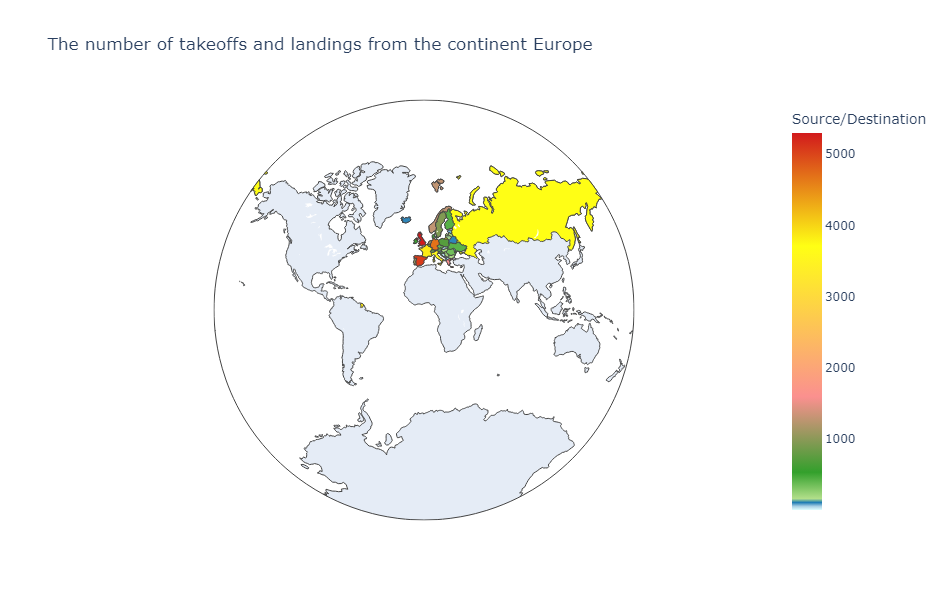

In [12]:
# Подготавливаем данные для изображения количества взлет/посадок случайного континента
data = dict(type='choropleth',
            locations=source_dest.index,
            locationmode='country names',
            z=source_dest['Source airport'] + source_dest['Destination airport'] ,
            text=source_dest.index,
            colorbar={'title': 'Source/Destination'},
            colorscale=[[0, 'rgb(225,255,255)'],
                        [0.01, 'rgb(166,206,227)'], [0.02, 'rgb(31,125,180)'],
                        [0.03, 'rgb(178,223,138)'], [0.10, 'rgb(51,160,44)'],
                        [0.30, 'rgb(251,144,143)'], [0.70, 'rgb(255,255,20)'],
                        [1, 'rgb(210,26,28)']],
            reversescale = False)

# Создаем макет карты
layout = dict(title=f'The number of takeoffs and landings from the continent {rand_cont}',
              autosize=False,
              width=800,
              height=600,
              geo=dict(showframe=True, projection={'type': 'van der grinten'}))

choromap = go.Figure(data=[data], layout=layout)
iplot(choromap, validate=False)

## Задание 6.
Для каждого континента найти 10 самых крупных аэропортов. Результат в виде датафрейма. Иерархический индекс: 1 уровень континенты по алфавиту, 2 уровень название аэропорта. В столбцах страна, город, код IATA и количество взлет посадок. Внутри континента аэропорты упорядочены по взлет/посадкам от наибольшего к наимельшему.

Нанести на карту Мира данные аэропорты разным цветом в зависимости от континента.

In [13]:
# Для случайного континента:

# Находим количество взлетов для каждой страны

merged_source = iata_arports[iata_arports.Continents == rand_cont].merge(routes, left_on="IATA", right_on="Source airport")
source = merged_source.pivot_table(index="Name of airport", values="Source airport", aggfunc="count")

# Находим количество посадок для каждой страны

merged_dist = iata_arports[iata_arports.Continents == rand_cont].merge(routes, left_on="IATA", right_on="Destination airport")
destination = merged_dist.pivot_table(index="Name of airport", values="Destination airport", aggfunc="count")

# Объединяем таблицы

source_dest_top = source.merge(destination, on="Name of airport").sort_values("Source airport", ascending=False)
source_dest_top["Source/Destination"] = source_dest_top["Source airport"] + source_dest_top["Destination airport"]
source_dest_top.sort_values(by="Source/Destination", ascending=False)

# Находим топ 10 аэропортов

merged_data = iata_arports.merge(source_dest_top, on="Name of airport").set_index(["Continents", "Name of airport"])
top_10 = merged_data[["City", "Country", "IATA", "Source/Destination"]].sort_values(by="Source/Destination", ascending=False)[:10]
display(top_10)

City         Country  \
Continents Name of airport                                                      
Europe     London Heathrow Airport                     London  United Kingdom   
           Charles de Gaulle International Airport      Paris          France   
           Frankfurt am Main Airport                Frankfurt         Germany   
           Amsterdam Airport Schiphol               Amsterdam     Netherlands   
           Barcelona International Airport          Barcelona           Spain   
           Munich Airport                              Munich         Germany   
           London Gatwick Airport                      London  United Kingdom   
           Leonardo da Vinci–Fiumicino Airport           Rome           Italy   
           Adolfo Suárez Madrid–Barajas Airport        Madrid           Spain   
           Domodedovo International Airport            Moscow          Russia   

                                                   IATA  Source/Destination  
Continents Name of airport                                                   
Europe     London Heathrow Airport                  LHR                1051  
           Charles de Gaulle International Airport  CDG                1041  
           Frankfurt am Main Airport                FRA                 990  
           Amsterdam Airport Schiphol               AMS                 903  
           Barcelona International Airport          BCN                 783  
           Munich Airport                           MUC                 728  
           London Gatwick Airport                   LGW                 708  
           Leonardo da Vinci–Fiumicino Airport      FCO                 662  
           Adolfo Suárez Madrid–Barajas Airport     MAD                 661  
           Domodedovo International Airport         DME                 649

## Задание 7.
В табличке `csv_routes_v1.csv` есть колонка `Equipment` - это код марки самолета в кодах IATA. Тут есть их расшифровка
https://en.wikipedia.org/wiki/List_of_aircraft_type_designators (если указаны два и более борта, считаем по перевому).

Найдите 10 самых популярных моделей самолетов, естественно с расшифровкой, с указанием количества рейсов выполняемых этими бортами (по числу посадок :)). Результат в виде датафрейма. Индекс номер по порядку, колонки - марка самолета и количество рейсов. Упорядочить от наибольшего количества рейсов вниз. 

In [14]:
url = 'https://en.wikipedia.org/wiki/List_of_aircraft_type_designators'
equip = pd.read_html(url)[0]
routes.Equipment = routes.Equipment.apply(lambda x: str(x).strip()[:3])
landing = routes.merge(equip, left_on="Equipment", right_on="IATA type code", how="left")
pop_model = landing.groupby(["Equipment", "Model"]).size().reset_index(name="Landings").sort_values(
    by="Landings", ascending=False)[:10].drop(["Equipment"], axis=1).reset_index(drop=True)
display(pop_model)

,Model,Landings
0,Airbus A320,11865
1,Boeing 737-800,8520
2,Airbus A319,5205
3,Boeing 737-800 Winglets,2566
4,Airbus A321,2145
5,Boeing 737-700 Winglets,1812
6,Embraer 190 / Lineage 1000,1391
7,Aerospatiale/Alenia ATR 72-201/-202,1387
8,Airbus A330-300,1211
9,De Havilland Canada DHC-8-400 Dash 8Q,1097
